In [1]:
import pandas as pd

# esp_results = pd.read_csv("results_esp_proteins.csv")
# esp_results["model"] = "ESP (state of the art)"

np_esm2_results = pd.read_csv("neural_net_esm2_no_stereo/results_neural_net_esm2_proteins.csv")
np_esm2_results["model"] = "Neural Network-NPClassifier-ESM2"
np_esm2_results = np_esm2_results.rename(columns={"f1_macro": "f1_score"})

# prosmith = pd.read_csv("prosmith_results_proteins.csv")
# prosmith["model"] = "ProSmith (state of the art)"

xgb_results = pd.read_csv("xgb_np_esm2_no_stereo/results_binding_np_classifier_proteins.csv")
xgb_results["model"] = "XGBoost-NPClassifierFP-ESM2"

xgb_results_prot_bert = pd.read_csv("xgb_np_prot_bert_no_stereo/results_binding_np_classifier_proteins.csv")
xgb_results_prot_bert["model"] = "XGBoost-NPClassifierFP-ProtBERT"

xgb_results_esm1b = pd.read_csv("xgb_np_esm1b_no_stereo/results_binding_np_classifier_proteins.csv")
xgb_results_esm1b["model"] = "XGBoost-NPClassifierFP-ESM1b"

In [2]:
results = pd.concat(
    [
        # esp_results,
        np_esm2_results,
        # prosmith,
        xgb_results,
        xgb_results_prot_bert,
        xgb_results_esm1b
    ]
)
results


,seed,fold,f1_score,precision,roc_auc,accuracy,mcc,recall,identity,model
0,1,0.0,0.726188,0.824713,0.869004,0.829909,0.614543,0.648692,40,Neural Network-NPClassifier-ESM2
1,2,0.0,0.743119,0.860603,0.882549,0.842820,0.645302,0.653859,40,Neural Network-NPClassifier-ESM2
2,3,0.0,0.773491,0.865654,0.905222,0.857640,0.679554,0.699064,40,Neural Network-NPClassifier-ESM2
3,4,0.0,0.747762,0.941205,0.917894,0.854496,0.679460,0.620278,40,Neural Network-NPClassifier-ESM2
4,5,0.0,0.788605,0.853383,0.911249,0.863366,0.692872,0.732967,40,Neural Network-NPClassifier-ESM2
...,...,...,...,...,...,...,...,...,...,...
15,0,NaN,0.981355,0.993554,0.993042,0.967793,0.866848,0.969452,20,XGBoost-NPClassifierFP-ESM1b
16,1,NaN,0.982712,0.995392,0.996041,0.970149,0.877457,0.970350,20,XGBoost-NPClassifierFP-ESM1b
17,2,NaN,0.981389,0.991743,0.994076,0.967793,0.864548,0.971249,20,XGBoost-NPClassifierFP-ESM1b
18,3,NaN,0.981590,0.981149,0.991296,0.967793,0.853069,0.982031,20,XGBoost-NPClassifierFP-ESM1b


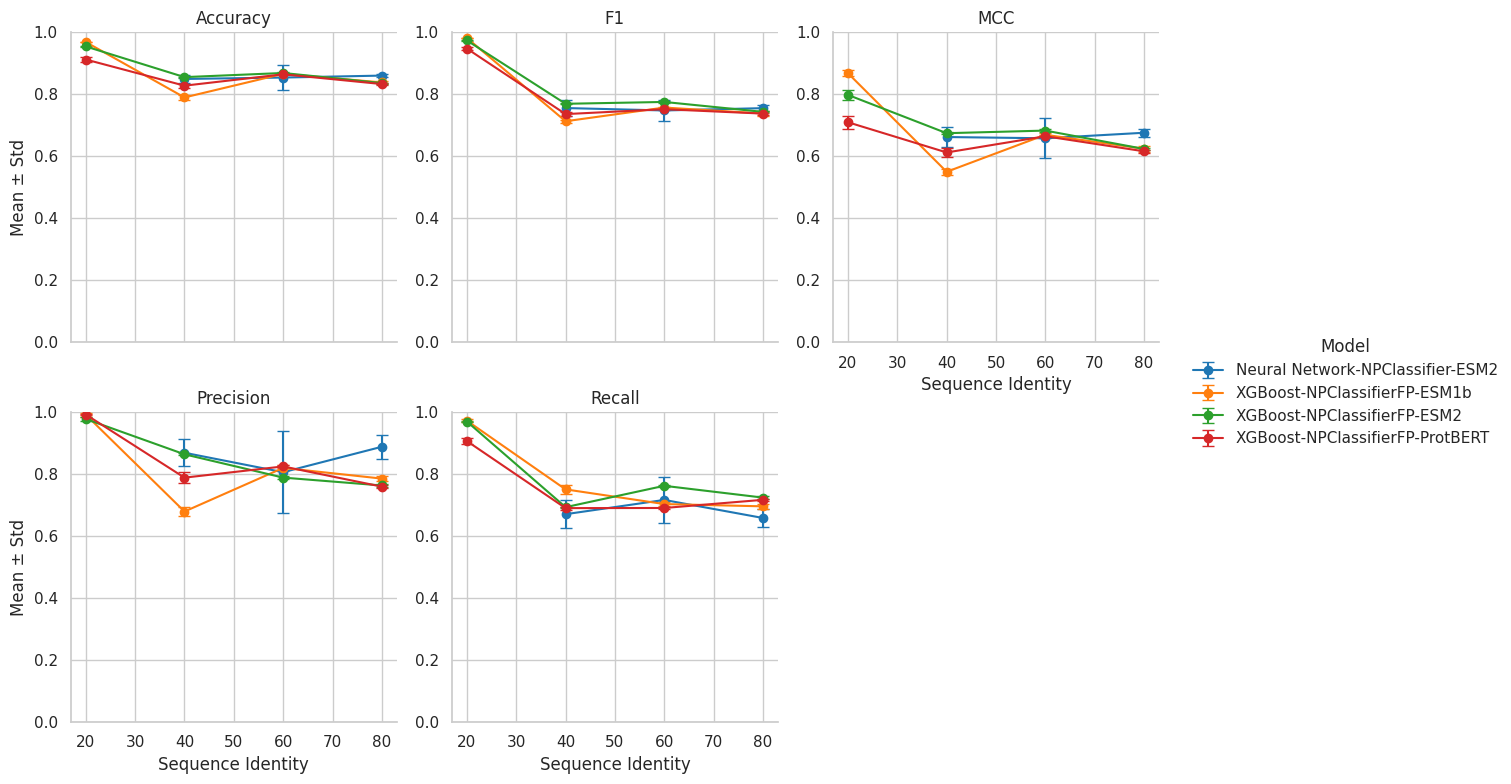

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Create a dictionary for column name mapping
column_mapping = {
    'f1_score': 'F1',
    'recall': 'Recall',
    'mcc': 'MCC',
    'precision': "Precision",
    'accuracy':"Accuracy"
}

# Rename columns in results dataframe
results = results.rename(columns=column_mapping)

# Melt for easier grouping
df_melted = results.melt(id_vars=['model', 'identity'],
                    value_vars=['Accuracy', 'F1', 'Recall', 'Precision', 'MCC'],
                    var_name='metric', value_name='value')

# Compute mean and std
summary_df = df_melted.groupby(['model', 'identity', 'metric']).agg(
    mean=('value', 'mean'),
    std=('value', 'std')
).reset_index()

# Set plot style
sns.set(style="whitegrid")
palette = sns.color_palette("tab10")

# Create FacetGrid
g = sns.FacetGrid(summary_df, col='metric', col_wrap=3, height=4, sharey=False, hue='model', palette=palette)

# Plot: lines + points + error bars
def plot_lines(data, color, **kwargs):
    # Sort by identity to ensure line plotting is correct
    data = data.sort_values('identity')
    plt.errorbar(data['identity'], data['mean'], yerr=data['std'], fmt='o-', 
                 capsize=4, color=color, label=data['model'].iloc[0])

g.map_dataframe(plot_lines)

# Titles and labels
g.set_titles("{col_name}")
g.set_axis_labels("Sequence Identity", "Mean ± Std")
g.add_legend(title="Model")
g.set(ylim=(0, 1))  # Set y-axis limits to [0, 1] for better visibility
g.tight_layout()
plt.savefig("results_proteins.png", dpi=300, transparent=True)
plt.show()

In [4]:
import pandas as pd

import pandas as pd

# esp_results = pd.read_csv("results_esp_compounds.csv")
# esp_results["model"] = "ESP (state of the art)"

np_esm2_results = pd.read_csv("neural_net_esm2_no_stereo/results_neural_net_esm2_compounds.csv")
np_esm2_results["model"] = "Neural Network-NPClassifier-ESM2"
np_esm2_results = np_esm2_results.rename(columns={"f1_macro": "f1_score"})

# prosmith = pd.read_csv("prosmith_results_compounds.csv")
# prosmith["model"] = "ProSmith (state of the art)"

xgb_results = pd.read_csv("xgb_np_esm2_no_stereo/results_binding_np_classifier_compounds.csv")
xgb_results["model"] = "XGBoost-NPClassifierFP-ESM2"

xgb_results_prot_bert = pd.read_csv("xgb_np_prot_bert_no_stereo/results_binding_np_classifier_compounds.csv")
xgb_results_prot_bert["model"] = "XGBoost-NPClassifierFP-ProtBERT"

xgb_results_esm1b = pd.read_csv("xgb_np_esm1b_no_stereo/results_binding_np_classifier_compounds.csv")
xgb_results_esm1b["model"] = "XGBoost-NPClassifierFP-ESM1b"

results = pd.concat(
    [
        # esp_results,
        np_esm2_results,
        # prosmith,
        xgb_results,
        xgb_results_prot_bert,
        xgb_results_esm1b
    ]
)
results


,seed,fold,f1_score,precision,roc_auc,accuracy,mcc,recall,similarity,model
0,1,0.0,0.491216,0.363592,0.859116,0.752339,0.394661,0.756895,20,Neural Network-NPClassifier-ESM2
1,2,0.0,0.399679,0.270622,0.796123,0.637464,0.277164,0.764045,20,Neural Network-NPClassifier-ESM2
2,3,0.0,0.489756,0.359256,0.860819,0.746854,0.394559,0.769152,20,Neural Network-NPClassifier-ESM2
3,4,0.0,0.505839,0.375619,0.864602,0.761052,0.414694,0.774259,20,Neural Network-NPClassifier-ESM2
4,5,0.0,0.437794,0.300380,0.835156,0.672636,0.335291,0.806946,20,Neural Network-NPClassifier-ESM2
...,...,...,...,...,...,...,...,...,...,...
15,0,NaN,0.554949,0.416709,0.900852,0.789610,0.480887,0.830439,20,XGBoost-NPClassifierFP-ESM1b
16,1,NaN,0.533593,0.391056,0.894962,0.768151,0.457877,0.839632,20,XGBoost-NPClassifierFP-ESM1b
17,2,NaN,0.559727,0.420297,0.903745,0.791868,0.487555,0.837589,20,XGBoost-NPClassifierFP-ESM1b
18,3,NaN,0.528877,0.387542,0.891959,0.765731,0.451136,0.832482,20,XGBoost-NPClassifierFP-ESM1b


In [5]:
# Create a dictionary for column name mapping
column_mapping = {
    'f1_score': 'F1',
    'recall': 'Recall',
    'mcc': 'MCC',
    'precision': "Precision",
    'accuracy':"Accuracy"
}

# Rename columns in results dataframe
results = results.rename(columns=column_mapping)

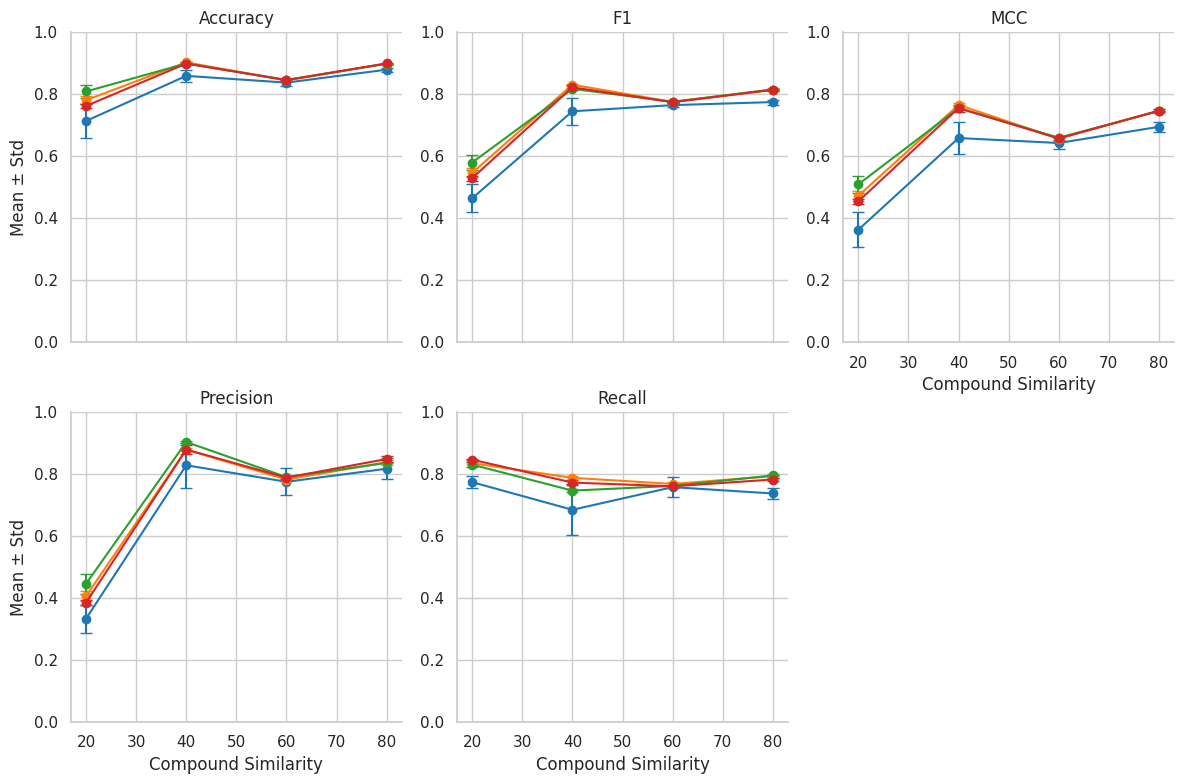

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Melt for easier grouping
df_melted = results.melt(id_vars=['model', 'similarity'],
                    value_vars=['Accuracy', 'F1', 'Recall', 'Precision', 'MCC'],
                    var_name='metric', value_name='value')
                    

# Compute mean and std
summary_df = df_melted.groupby(['model', 'similarity', 'metric']).agg(
    mean=('value', 'mean'),
    std=('value', 'std')
).reset_index()

# Set plot style
sns.set(style="whitegrid")
palette = sns.color_palette("tab10")

# Create FacetGrid
g = sns.FacetGrid(summary_df, col='metric', col_wrap=3, height=4, sharey=False, hue='model', palette=palette)

# Plot: lines + points + error bars
def plot_lines(data, color, **kwargs):
    # Sort by identity to ensure line plotting is correct
    data = data.sort_values('similarity')
    plt.errorbar(data['similarity'], data['mean'], yerr=data['std'], fmt='o-', 
                 capsize=4, color=color, label=data['model'].iloc[0])

g.map_dataframe(plot_lines)

# Titles and labels
g.set_titles("{col_name}")
g.set_axis_labels("Compound Similarity", "Mean ± Std")
# g.add_legend(title="Model")
g.set(ylim=(0, 1))  # Set y-axis limits to [0, 1] for better visibility
g.tight_layout()
plt.savefig("results.png", dpi=300, transparent=True)
plt.show()
plt.close()

g.add_legend(title="Model")
g.savefig(f"legend_compounds.png", bbox_inches='tight', dpi=300, transparent=True)

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from math import pi


def generate_metric_radar_plot(models, compound_files, similarity, metric='mcc'):
    # Dicionário para armazenar os valores de MCC por modelo e composto
    all_mcc_values = {model: {} for model in models}

    # Loop por cada modelo
    for model in models:
        # Loop por cada tipo de composto
        for compound, file in compound_files.items():
            try:
                df = pd.read_csv(os.path.join(model, file))  # Assumindo que os ficheiros estão na mesma pasta
                df = df[df["similarity"] == similarity]
                all_mcc_values[model][compound] = df[metric].mean()
            except Exception as e:
                print(f"Erro ao processar {model}/{compound}: {e}")

    # Preparar dados para o radar chart
    categories = list(compound_files.keys())
    N = len(categories)

    # Ângulos para cada eixo no radar chart
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  # Fechar o círculo

    # Inicializar o gráfico
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'polar': True})

    for i, model in enumerate(all_mcc_values):
        values = list(all_mcc_values[model].values())
        values += values[:1] 
        ax.plot(angles, values, linewidth=2, label=model)
        ax.fill(angles, values, alpha=0.1)

    # Configurar o gráfico
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_title('Comparação de MCC por Tipo de Composto e Modelo', size=16, y=1.1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

    plt.tight_layout()
    plt.savefig('compound_mcc_radar_chart_all_models.png', dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()

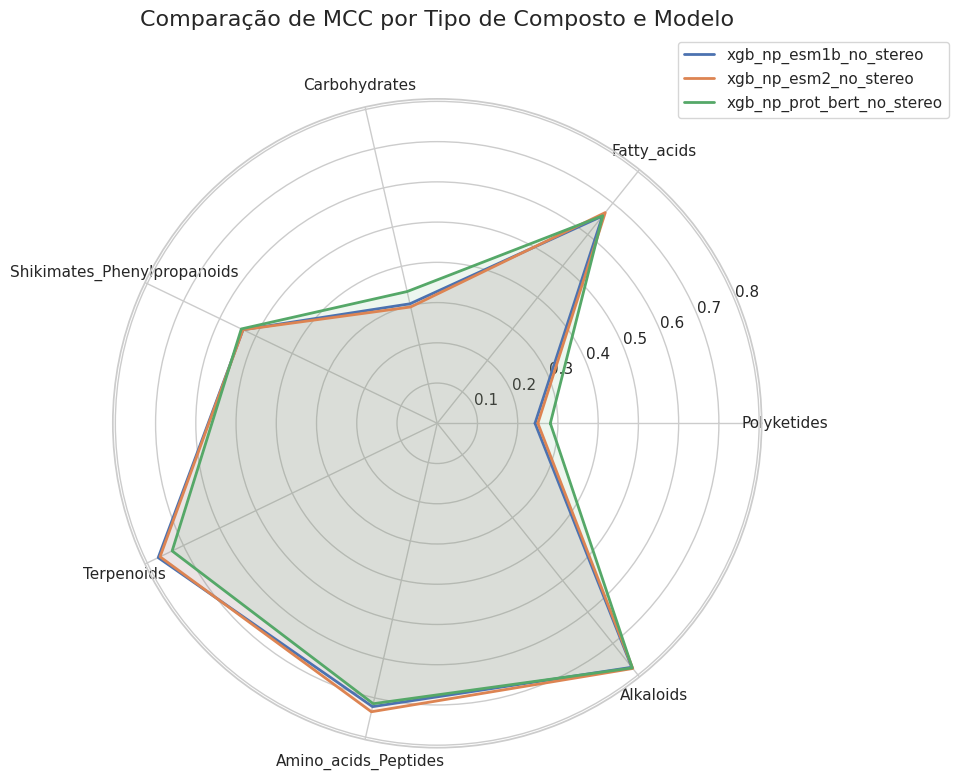

In [22]:
models = ["xgb_np_esm1b_no_stereo", "xgb_np_esm2_no_stereo", "xgb_np_prot_bert_no_stereo"]

# Dicionário de ficheiros de compostos
compound_files = {
    "Polyketides": "results_binding_np_classifier_compounds_Polyketides.csv",
    "Fatty_acids": "results_binding_np_classifier_compounds_Fatty acids.csv",
    "Carbohydrates": "results_binding_np_classifier_compounds_Carbohydrates.csv",
    "Shikimates_Phenylpropanoids": "results_binding_np_classifier_compounds_Shikimates and Phenylpropanoids.csv",
    "Terpenoids": "results_binding_np_classifier_compounds_Terpenoids.csv",
    "Amino_acids_Peptides": "results_binding_np_classifier_compounds_Amino acids and Peptides.csv",
    "Alkaloids": "results_binding_np_classifier_compounds_Alkaloids.csv"
}

generate_metric_radar_plot(models, compound_files, 60, metric='mcc')